In [1]:
import pandas as pd
from sqlalchemy import create_engine
from urllib.parse import quote
from matplotlib import pyplot as plt
import seaborn as sns

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
# параметры подключения
username = "student"
password = "123456sql@"
host = "rc1b-cpsjckr2wfkuk61s.mdb.yandexcloud.net"
port = "6432"
database = "Northwind"

# Кодируем пароль
encoded_password = quote(password)
print(encoded_password)

# Формируем строку подключения
connection_string = f'postgresql+psycopg2://{username}:{encoded_password}@{host}:{port}/{database}'
engine = create_engine(connection_string)

123456sql%40


In [3]:
#sql запрос
query = """
with t1 as (
select seller_id, date(date_trunc('month', min(date_created))) as cohort_month
from sandbox.orders o join  sandbox.order_details od on o.order_id = od.order_id 
group by seller_id
)
select 
cohort_month,
date(date_trunc('month',date_created)) as  purchase_month,
row_number()over(partition by cohort_month order by date(date_trunc('month',date_created))) purchase_month_number,
count(distinct od.seller_id) as sellers_created,
sum(quantity * price)/count(distinct od.seller_id) as arpps_created,
sum(quantity * price) as gmv_created
from sandbox.orders o join  sandbox.order_details od on o.order_id = od.order_id 
join t1 on od.seller_id = t1.seller_id
group by cohort_month, date(date_trunc('month', date_created))
order by cohort_month, date(date_trunc('month', date_created))
"""
df = pd.read_sql_query(query, engine)
df.head()

,cohort_month,purchase_month,purchase_month_number,sellers_created,arpps_created,gmv_created
0,2017-01-01,2017-01-01,1,214,523.739766,112080.31
1,2017-01-01,2017-02-01,2,161,814.404596,131119.14
2,2017-01-01,2017-03-01,3,159,1145.889434,182196.42
3,2017-01-01,2017-04-01,4,137,1217.180000,166753.66
4,2017-01-01,2017-05-01,5,143,1536.237413,219681.95


#### Считаем размер когорт

In [4]:
pivot_table = df.pivot_table(
    index='cohort_month',   # Строки - месяцы когорт
    columns='purchase_month_number',  # Столбцы - месяцы покупок
    values='sellers_created',  # Значения - количество селлеров с покупкой (active sellers)
)

In [5]:
pivot_table

purchase_month_number,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
cohort_month,,,,,,,,,,,,,,,,,,,
2017-01-01,214.0,161.0,159.0,137.0,143.0,135.0,124.0,133.0,121.0,123.0,121.0,109.0,113.0,107.0,109.0,100.0,85.0,86.0,56.0
2017-02-01,222.0,139.0,127.0,130.0,104.0,115.0,111.0,102.0,102.0,100.0,102.0,89.0,85.0,85.0,91.0,72.0,77.0,54.0,NaN
2017-03-01,170.0,103.0,97.0,87.0,84.0,83.0,77.0,72.0,84.0,66.0,68.0,62.0,60.0,57.0,53.0,53.0,33.0,NaN,NaN
2017-04-01,110.0,62.0,50.0,60.0,55.0,52.0,44.0,55.0,47.0,45.0,36.0,39.0,36.0,34.0,28.0,21.0,NaN,NaN,NaN
2017-05-01,117.0,61.0,57.0,62.0,57.0,54.0,53.0,47.0,51.0,52.0,47.0,42.0,37.0,31.0,22.0,NaN,NaN,NaN,NaN
2017-06-01,71.0,29.0,28.0,32.0,23.0,29.0,28.0,25.0,19.0,22.0,21.0,18.0,16.0,11.0,NaN,NaN,NaN,NaN,NaN
2017-07-01,110.0,73.0,67.0,67.0,74.0,70.0,65.0,61.0,60.0,59.0,58.0,58.0,36.0,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,117.0,64.0,58.0,67.0,54.0,55.0,61.0,54.0,50.0,47.0,47.0,24.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,118.0,64.0,64.0,56.0,63.0,50.0,57.0,52.0,51.0,43.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Считаем Retention Rate, %

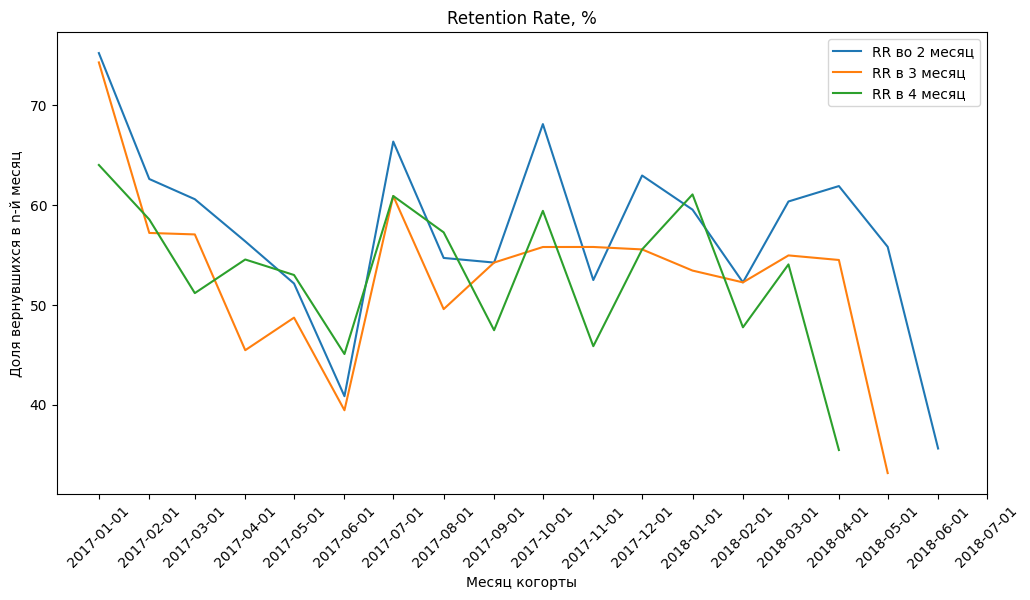

In [6]:
#retention rate во второй месяц
plt.figure(figsize=(12, 6))
plt.plot(pivot_table[2]/pivot_table[1]*100, label='RR во 2 месяц') #добавление лейбла
plt.plot(pivot_table[3]/pivot_table[1]*100, label='RR в 3 месяц') 
plt.plot(pivot_table[4]/pivot_table[1]*100, label='RR в 4 месяц')
plt.legend() #функция для того, чтобы лейблы отображались
plt.title('Retention Rate, %')
plt.xlabel('Месяц когорты')
plt.ylabel('Доля вернувшихся в n-й месяц')
plt.xticks(pivot_table.index,rotation = 45)
plt.show()

In [7]:
# Считаем долю для всех месяцев
pivot_table = pivot_table.div(pivot_table[1], axis=0) * 100

In [8]:
pivot_table

purchase_month_number,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
cohort_month,,,,,,,,,,,,,,,,,,,
2017-01-01,100.0,75.233645,74.299065,64.018692,66.822430,63.084112,57.943925,62.149533,56.542056,57.476636,56.542056,50.934579,52.803738,50.000000,50.934579,46.728972,39.719626,40.186916,26.168224
2017-02-01,100.0,62.612613,57.207207,58.558559,46.846847,51.801802,50.000000,45.945946,45.945946,45.045045,45.945946,40.090090,38.288288,38.288288,40.990991,32.432432,34.684685,24.324324,NaN
2017-03-01,100.0,60.588235,57.058824,51.176471,49.411765,48.823529,45.294118,42.352941,49.411765,38.823529,40.000000,36.470588,35.294118,33.529412,31.176471,31.176471,19.411765,NaN,NaN
2017-04-01,100.0,56.363636,45.454545,54.545455,50.000000,47.272727,40.000000,50.000000,42.727273,40.909091,32.727273,35.454545,32.727273,30.909091,25.454545,19.090909,NaN,NaN,NaN
2017-05-01,100.0,52.136752,48.717949,52.991453,48.717949,46.153846,45.299145,40.170940,43.589744,44.444444,40.170940,35.897436,31.623932,26.495726,18.803419,NaN,NaN,NaN,NaN
2017-06-01,100.0,40.845070,39.436620,45.070423,32.394366,40.845070,39.436620,35.211268,26.760563,30.985915,29.577465,25.352113,22.535211,15.492958,NaN,NaN,NaN,NaN,NaN
2017-07-01,100.0,66.363636,60.909091,60.909091,67.272727,63.636364,59.090909,55.454545,54.545455,53.636364,52.727273,52.727273,32.727273,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,100.0,54.700855,49.572650,57.264957,46.153846,47.008547,52.136752,46.153846,42.735043,40.170940,40.170940,20.512821,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,100.0,54.237288,54.237288,47.457627,53.389831,42.372881,48.305085,44.067797,43.220339,36.440678,16.101695,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


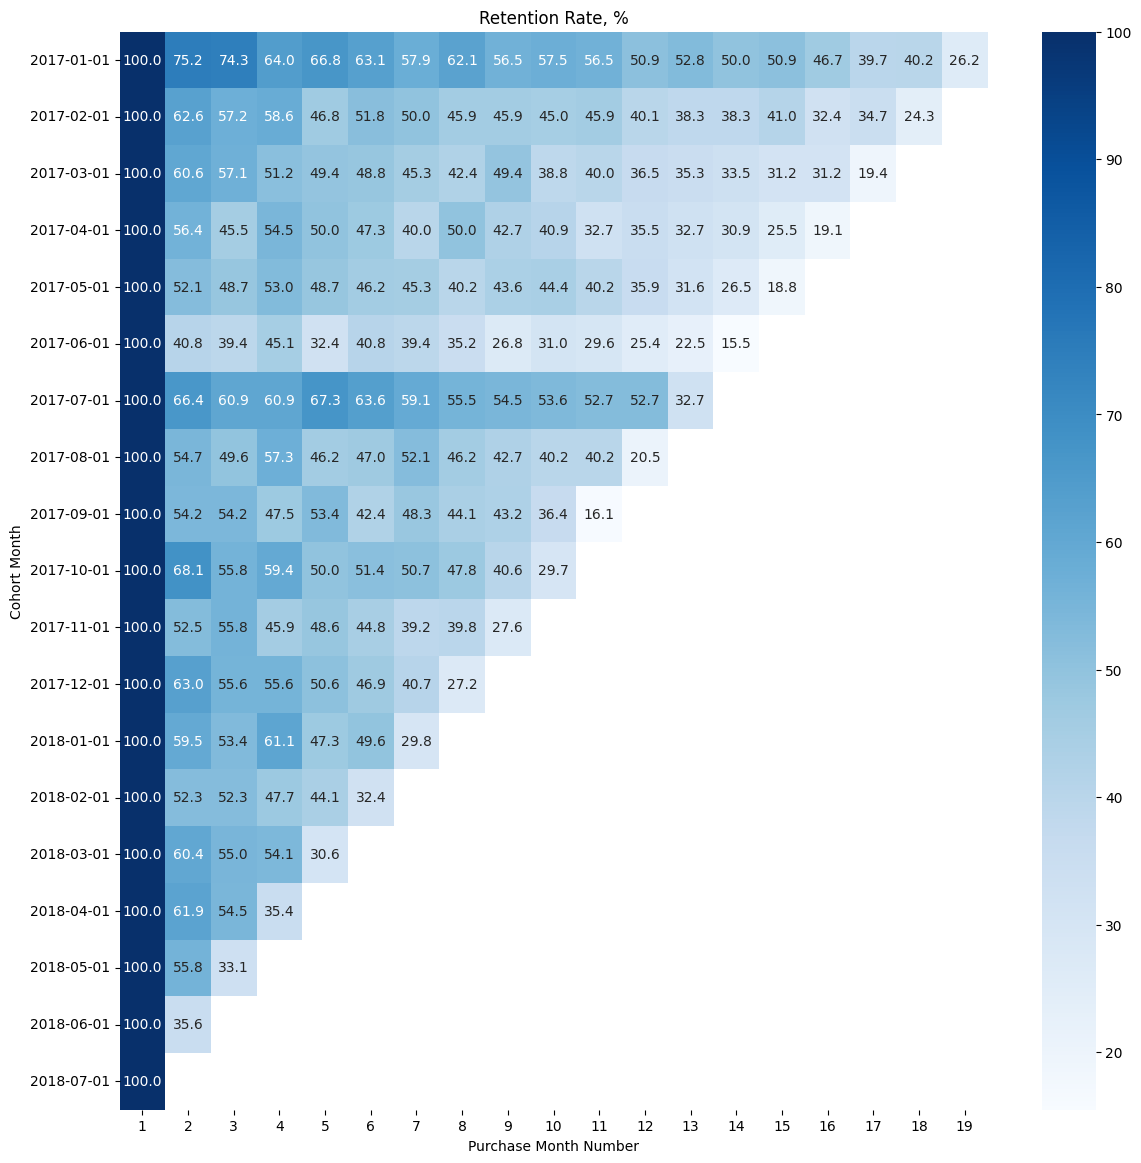

In [9]:
# Построение графика
plt.figure(figsize=(14, 14))
sns.heatmap(pivot_table, annot=True, fmt=".1f", cmap='Blues')
plt.title('Retention Rate, %')
plt.ylabel('Cohort Month')
plt.xlabel('Purchase Month Number')
plt.show()

#### Считаем Average Revenue Per Paying Seller

In [10]:
df.head()

,cohort_month,purchase_month,purchase_month_number,sellers_created,arpps_created,gmv_created
0,2017-01-01,2017-01-01,1,214,523.739766,112080.31
1,2017-01-01,2017-02-01,2,161,814.404596,131119.14
2,2017-01-01,2017-03-01,3,159,1145.889434,182196.42
3,2017-01-01,2017-04-01,4,137,1217.180000,166753.66
4,2017-01-01,2017-05-01,5,143,1536.237413,219681.95


In [11]:
df_arpps_pivot = df.pivot_table(
    index='cohort_month',   # Строки - месяцы когорт
    columns='purchase_month_number',  # Столбцы - месяцы покупок
    values='arpps_created',  # Значения - average revenue per pay paying seller
)

In [12]:
df_arpps_pivot

purchase_month_number,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
cohort_month,,,,,,,,,,,,,,,,,,,
2017-01-01,523.739766,814.404596,1145.889434,1217.180000,1536.237413,1278.132074,1473.534435,1243.876692,1331.786777,1447.794065,1915.274959,1467.466330,1568.669204,1505.159159,1704.966514,1332.038700,1298.410941,1068.262326,549.548214
2017-02-01,434.370721,699.380360,694.346299,713.826846,790.809135,792.075043,765.750901,822.738922,784.414510,1216.496300,1093.746667,1253.394607,901.032588,1053.426471,905.207253,1180.808611,829.908701,517.629815,NaN
2017-03-01,442.565412,421.273495,819.813299,722.701149,842.358929,916.540964,1107.575974,1155.130694,1371.007619,1282.343939,1433.769706,1302.323710,1366.650500,1210.930351,1086.451132,1296.762642,562.768182,NaN,NaN
2017-04-01,315.088273,595.428548,657.413000,683.894833,725.756364,895.691154,977.005909,1091.168364,796.450000,885.954222,1108.889167,939.560000,924.664167,1047.493824,866.945000,655.116667,NaN,NaN,NaN
2017-05-01,466.579316,639.586885,892.775789,858.238387,769.799825,682.228889,916.188868,875.481702,781.335686,570.020769,708.756596,609.548810,552.768919,542.116129,311.044545,NaN,NaN,NaN,NaN
2017-06-01,432.694930,569.206207,423.035714,416.496250,337.129130,528.793793,407.913929,318.092000,450.111579,506.366818,462.769524,579.812778,410.111875,339.052727,NaN,NaN,NaN,NaN,NaN
2017-07-01,285.696091,631.321096,791.935373,794.759851,1216.809595,757.277286,1196.870462,1141.836721,1432.322000,1569.511017,1698.466552,1189.697241,505.289722,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,645.149915,1386.813125,1179.814138,834.754179,951.311296,862.472545,559.733279,563.780185,653.151400,512.397021,508.109574,283.688333,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,259.024153,360.285937,666.147031,540.151607,806.422540,887.451800,620.308596,703.462692,679.790588,743.559767,374.021053,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


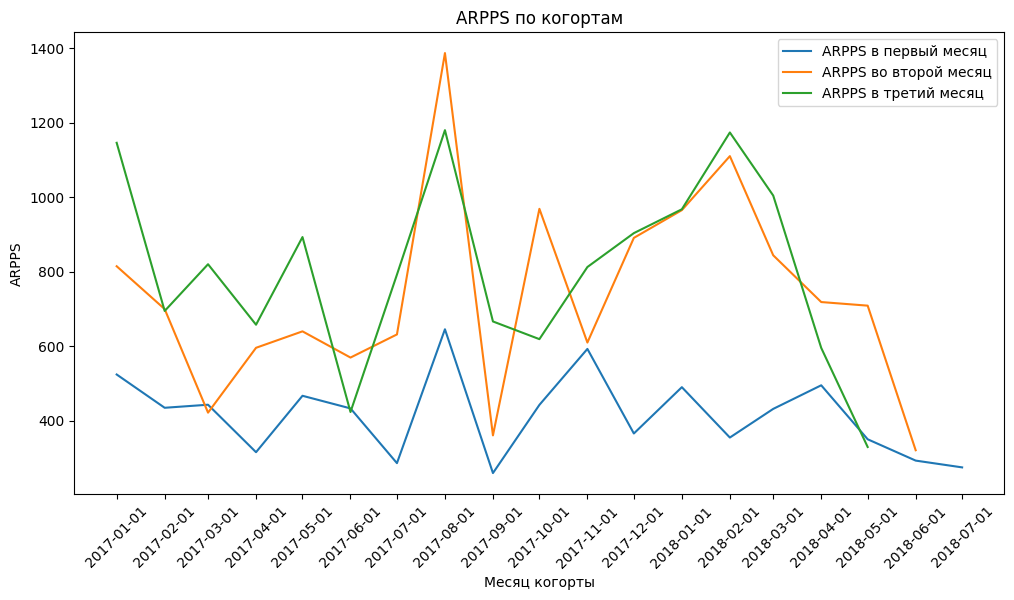

In [15]:
#сравнить ARPPS когорт в первый месяц жизни, во второй, третий
plt.figure(figsize=(12, 6))
plt.plot(df_arpps_pivot[1], label = 'ARPPS в первый месяц')
plt.plot(df_arpps_pivot[2], label = 'ARPPS во второй месяц')
plt.plot(df_arpps_pivot[3], label = 'ARPPS в третий месяц')
plt.legend()
plt.ylabel('ARPPS')
plt.xlabel('Месяц когорты')
plt.title('ARPPS по когортам')
plt.xticks(pivot_table.index,rotation = 45)
plt.show()

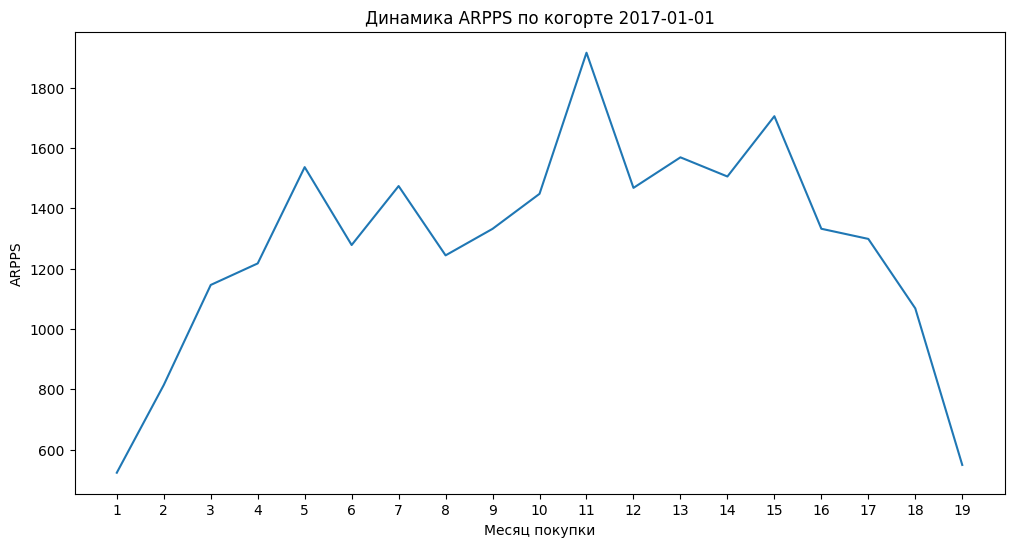

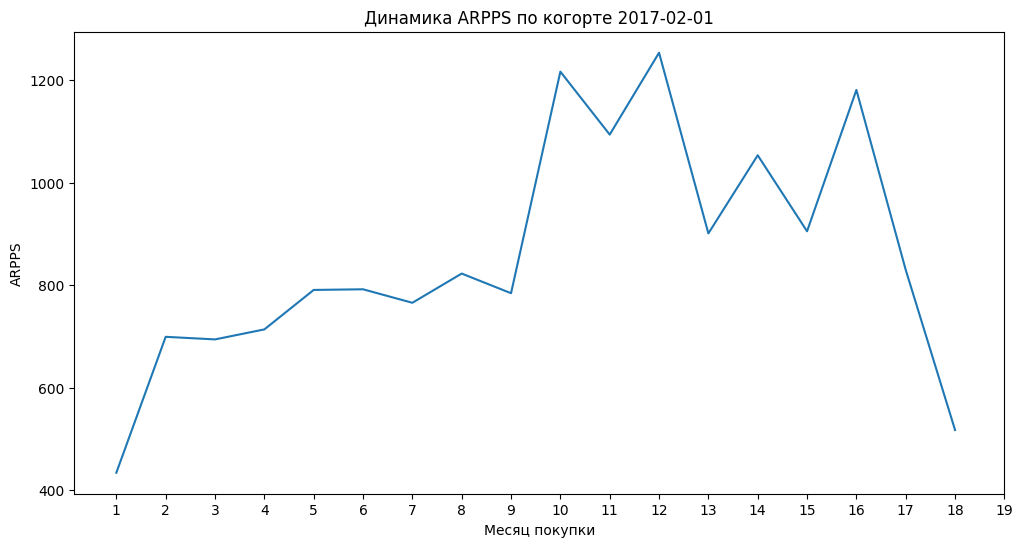

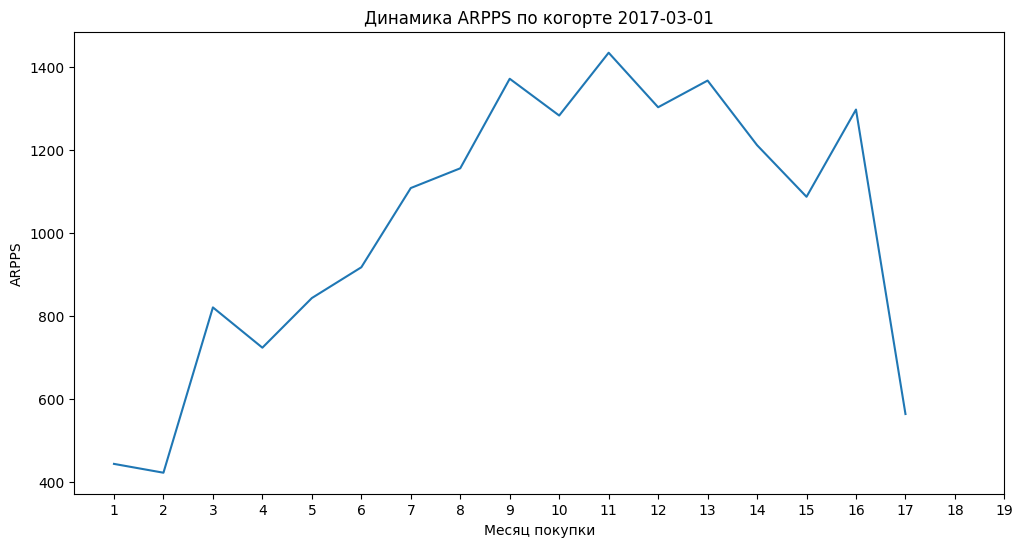

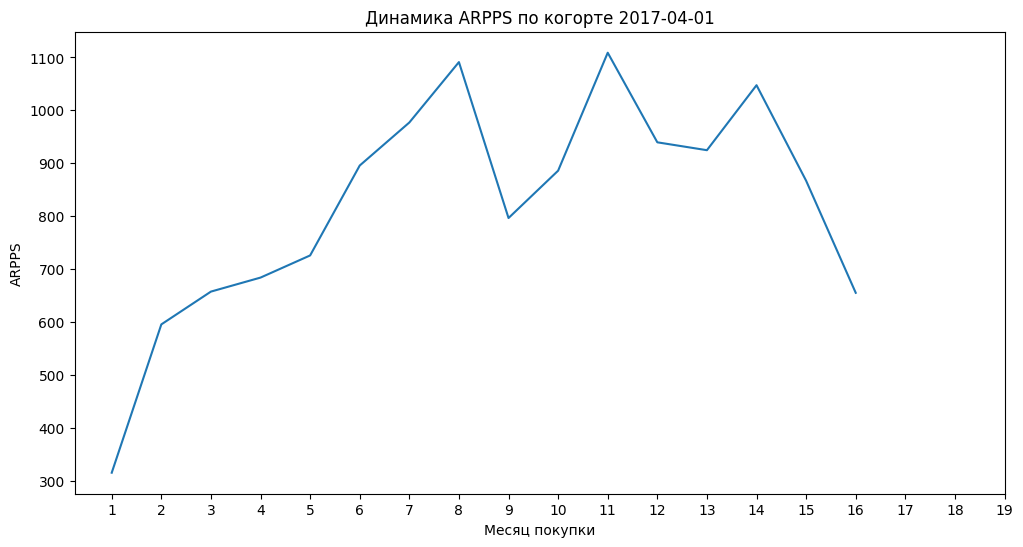

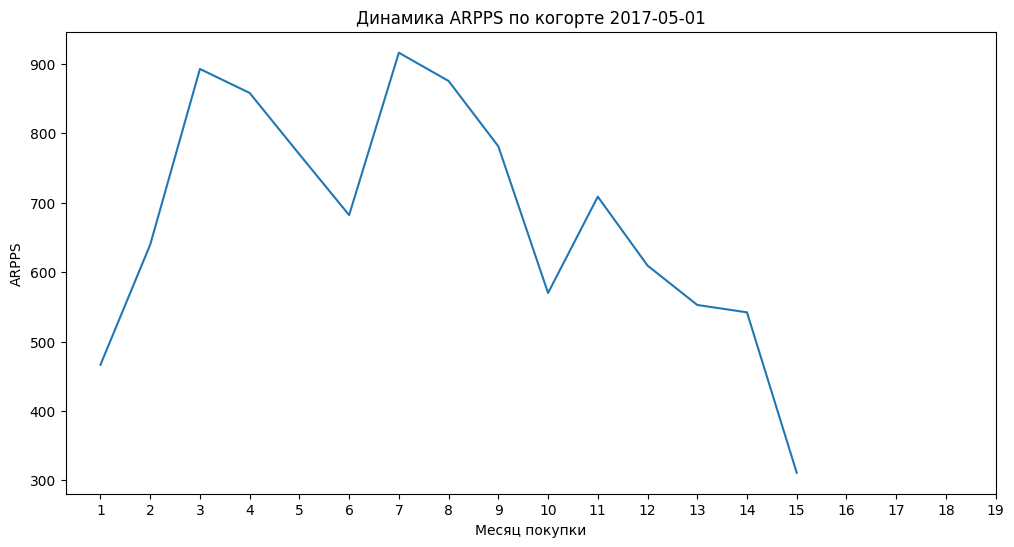

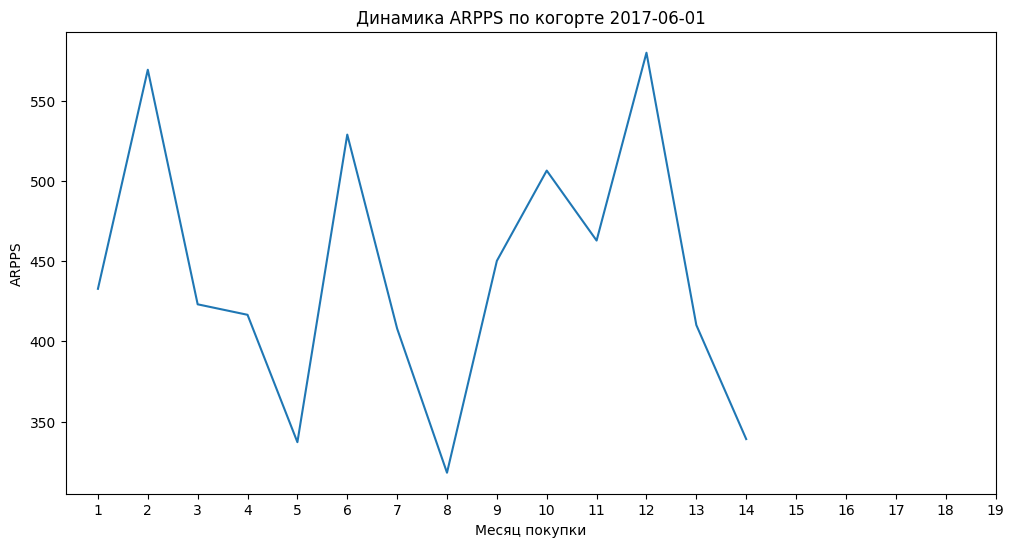

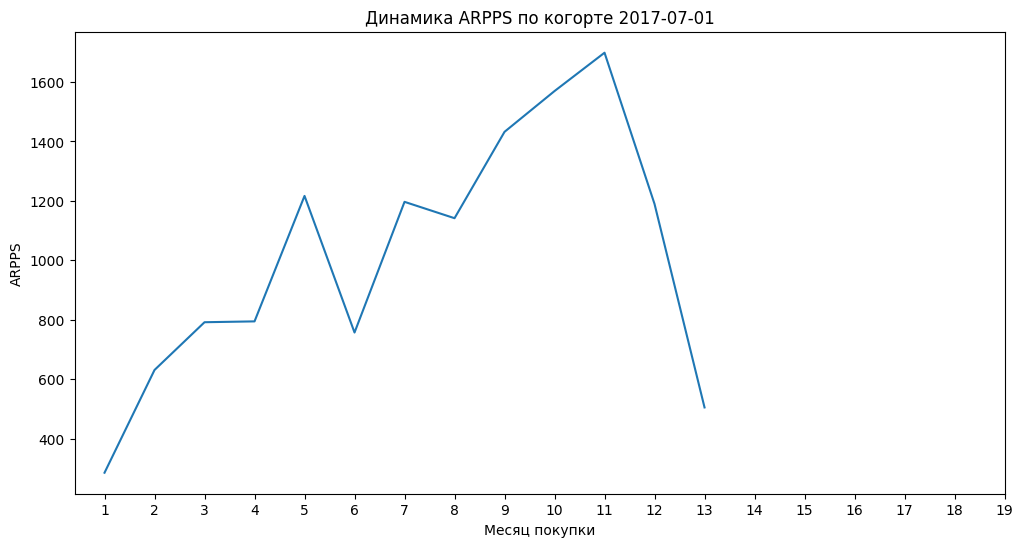

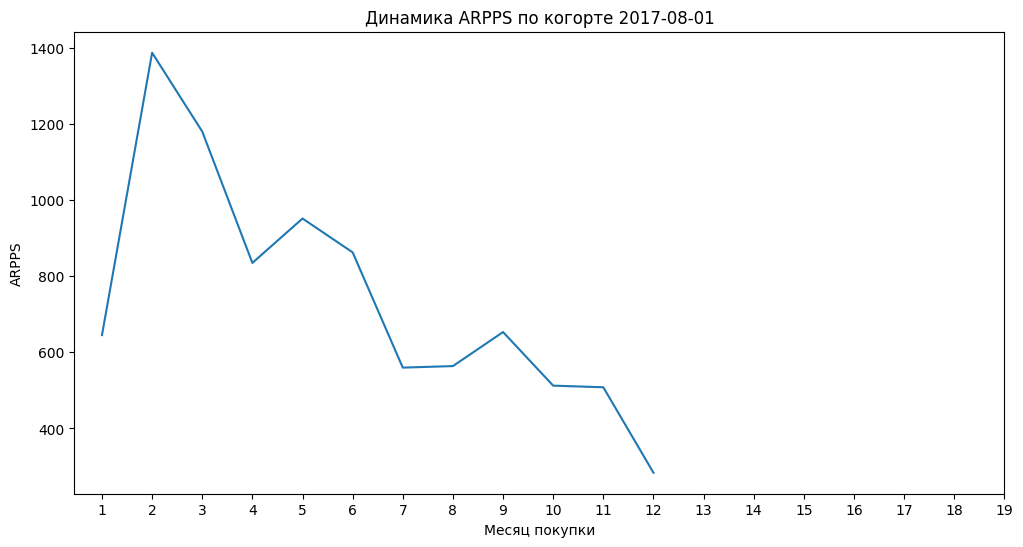

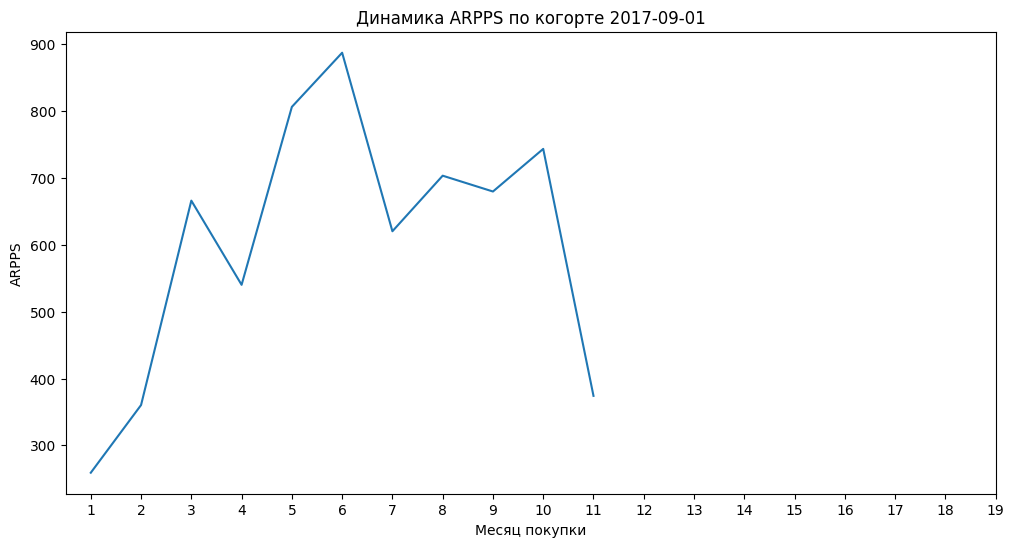

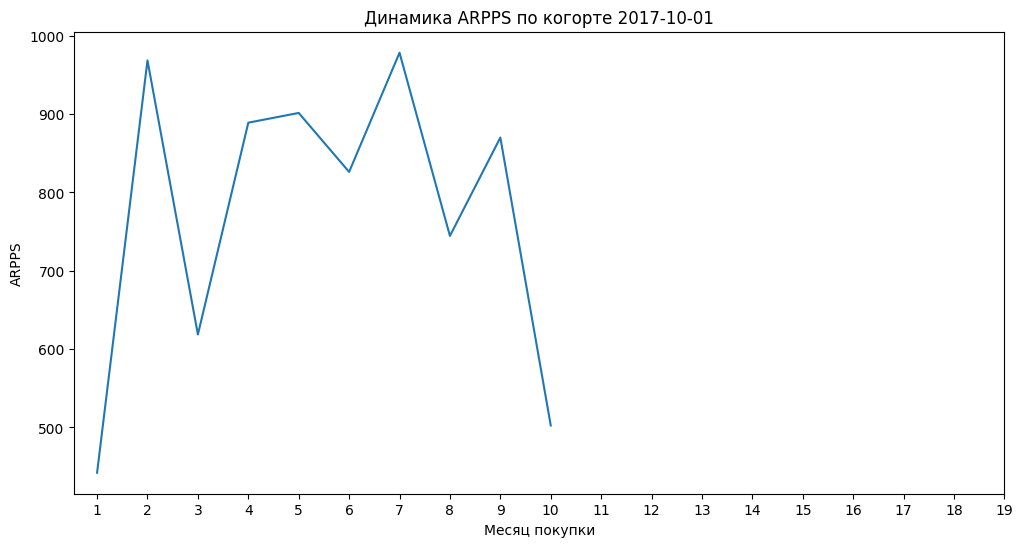

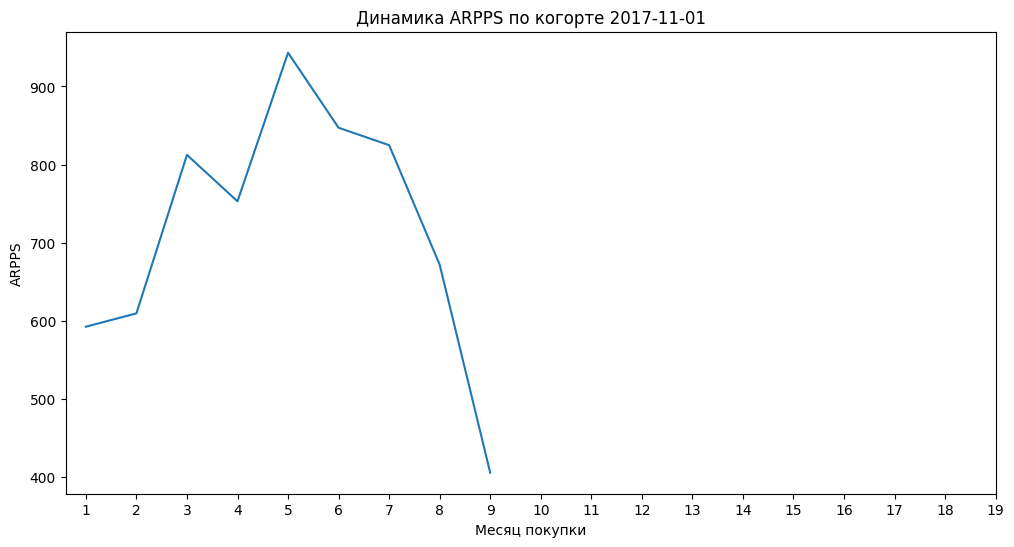

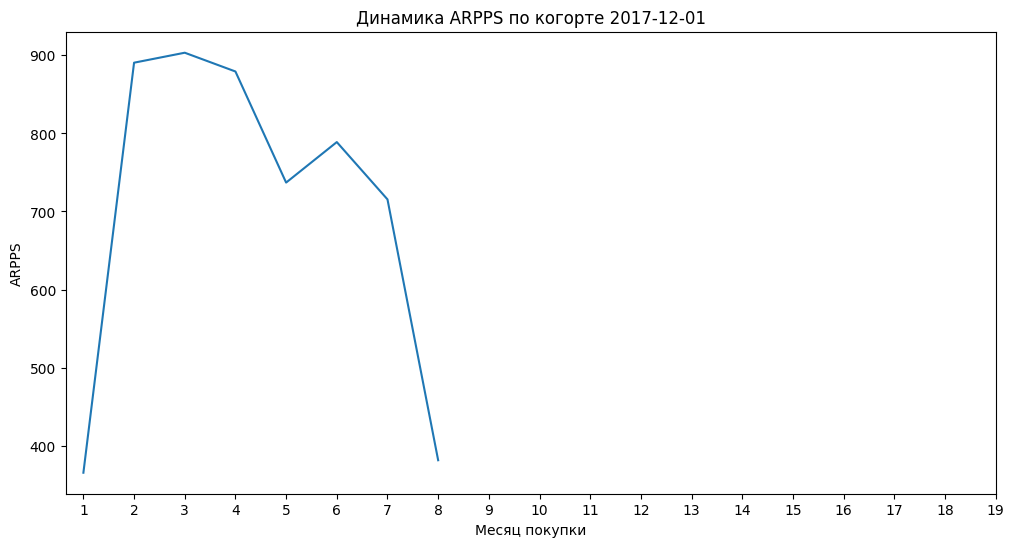

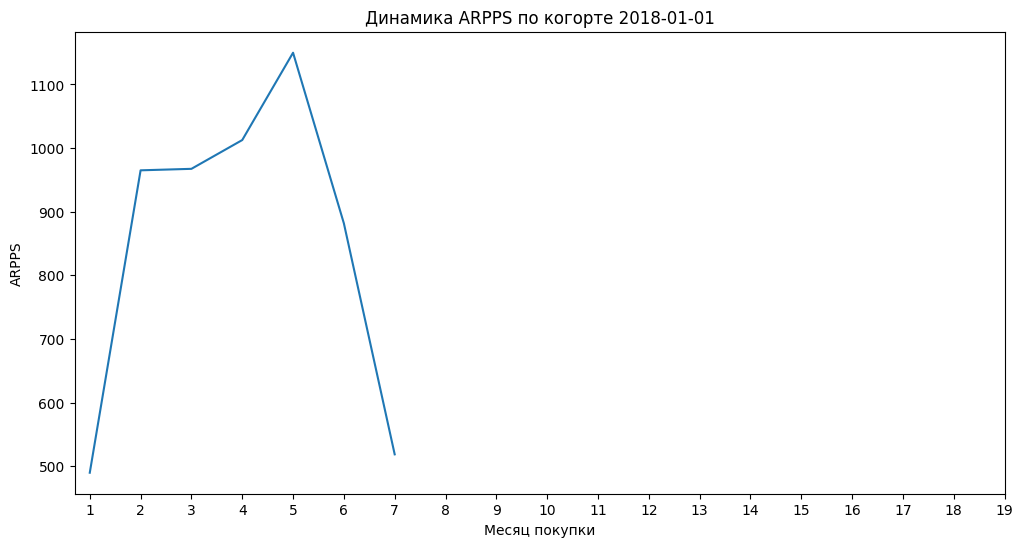

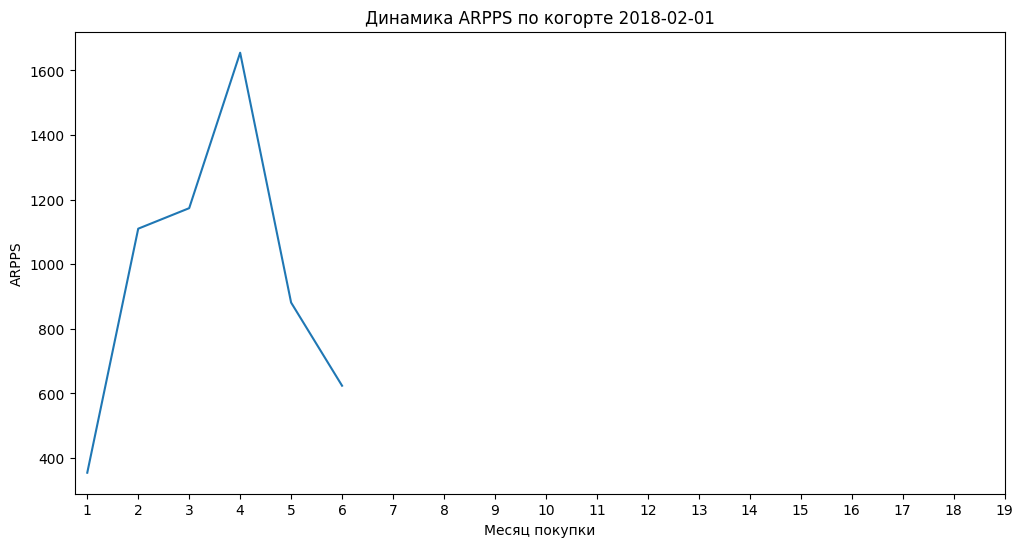

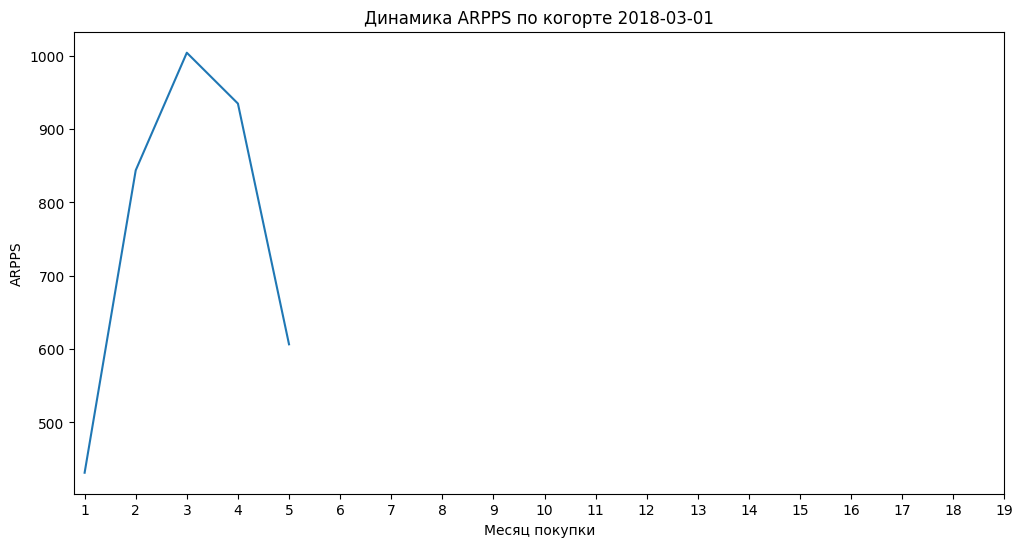

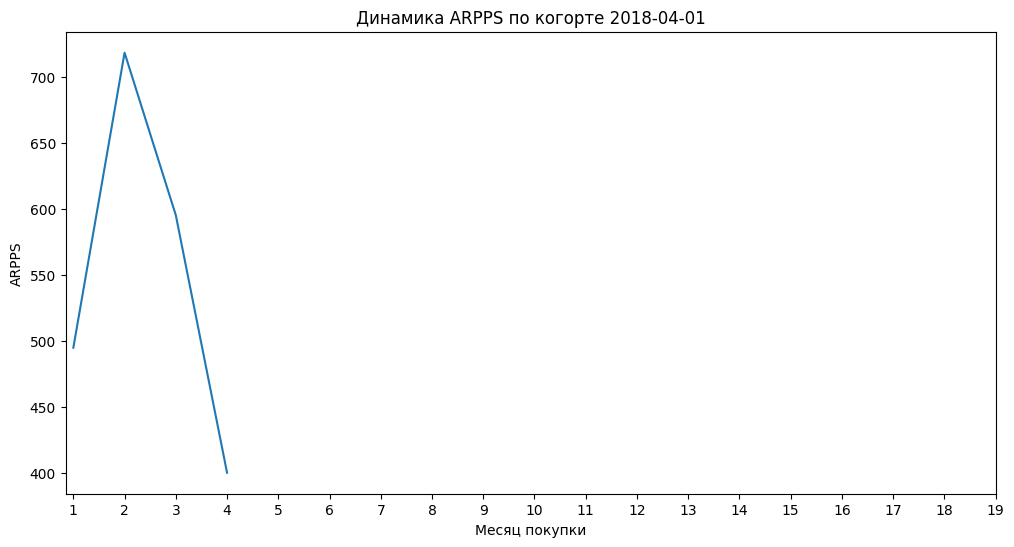

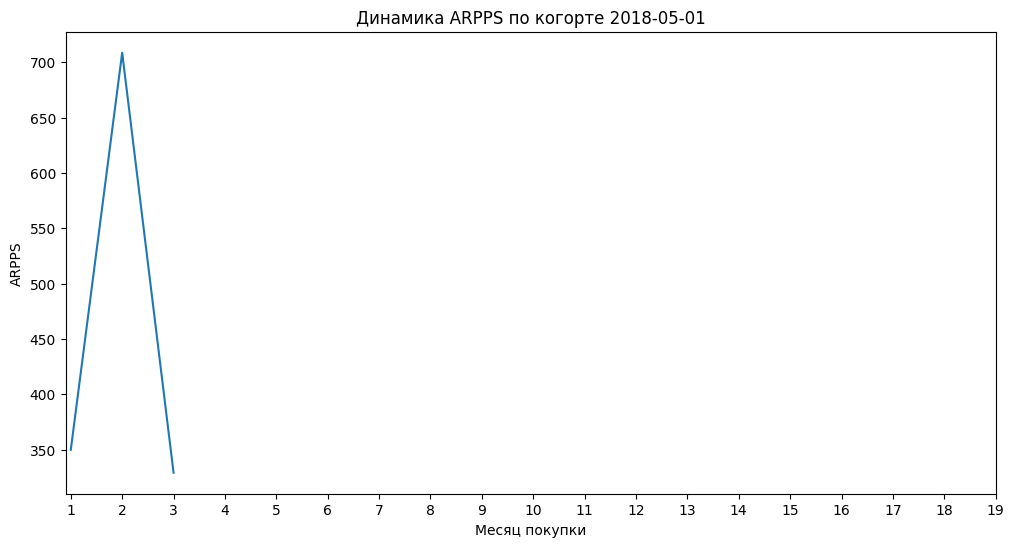

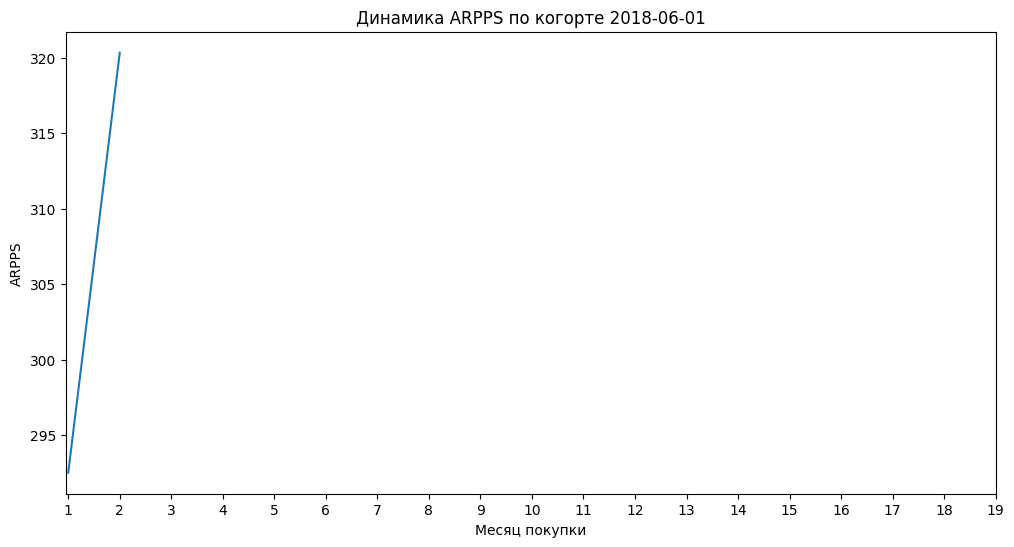

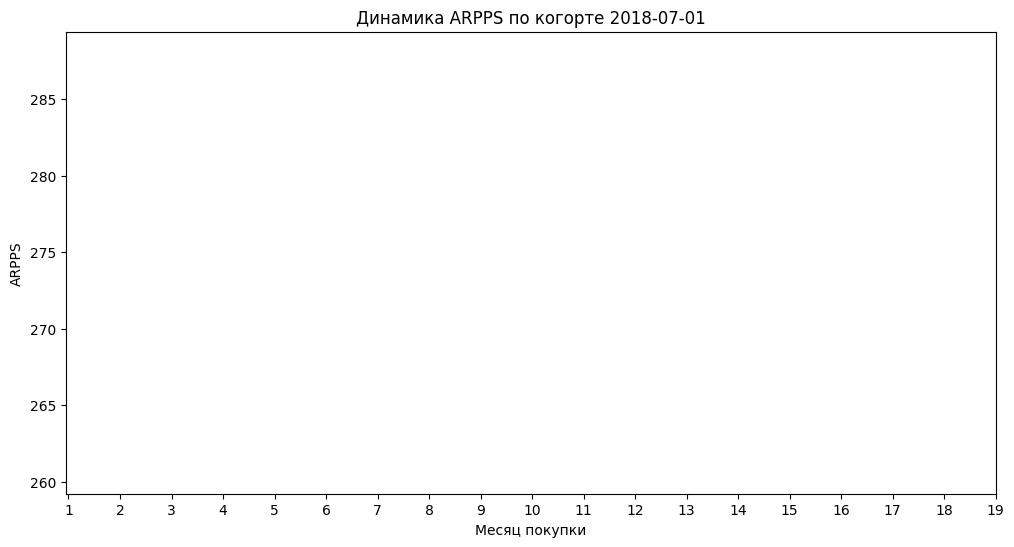

In [16]:
#поведение по каждой когорте из месяца в месяц
for i in range(0, df_arpps_pivot.shape[0]):
    plt.figure(figsize=(12, 6))
    plt.plot(df_arpps_pivot.iloc[i])
    plt.title('Динамика ARPPS по когорте ' + str(df_arpps_pivot.iloc[i].name)[:11])
    plt.xlabel('Месяц покупки')
    plt.ylabel('ARPPS')
    plt.xticks(df_arpps_pivot.columns)
    plt.show()